In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from tqdm import tqdm
import json
import scipy.stats as stats

from matplotlib.ticker import MultipleLocator, LogLocator

with open("matplotlibrc.json") as f:
    mpl.rcParams.update(json.load(f))

In [2]:
META = ["QECC", "n", "k", "d", "noise-model", "method"]
PARAMS = ["clifford_deformation", "p", "eta"]

def load_ler_csv(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, dtype={"clifford_deformation": str})
    # results.csv stores a Beta(1,1) posterior: alpha = failures + 1, beta = successes + 1
    df["failures"] = df["alpha"] - 1
    df["successes"] = df["beta"] - 1

    keys = [c for c in PARAMS if c in df.columns]
    df = df.groupby(keys, as_index=False).agg(
        failures=("failures", "sum"),
        successes=("successes", "sum"),
        shots=("shots", "sum"),
        repeats=("seed", "size"),
        **{c: (c, "first") for c in META if c in df.columns},
    )
    # one prior for the pooled data, not one per repeat
    df["alpha"] = df["failures"] + 1
    df["beta"] = df["successes"] + 1
    a, b = df["alpha"], df["beta"]
    df["ler"] = a / (a + b)
    df["ler_var"] = a * b / (a + b) ** 2 / (a + b + 1)
    df["ler_unc"] = np.sqrt(df["ler_var"])
    return df


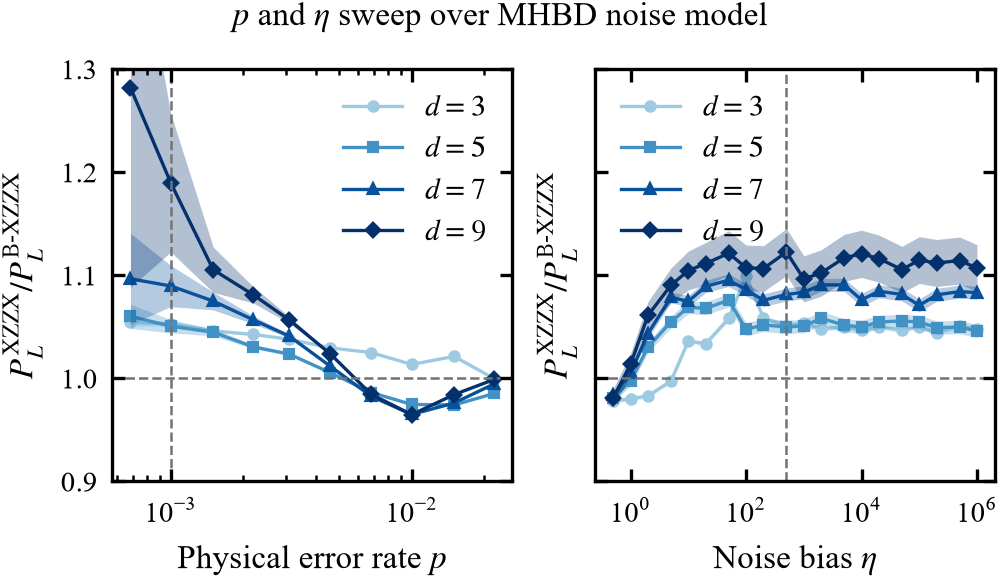

In [35]:
p_sweep = {
    3: load_ler_csv("../results/thresshold/SC3_MHBD_MWPM_p_sweep/results.csv"),
    5: load_ler_csv("../results/thresshold/SC5_MHBD_MWPM_p_sweep/results.csv"),
    7: load_ler_csv("../results/thresshold/SC7_MHBD_MWPM_p_sweep/results.csv"),
    9: load_ler_csv("../results/thresshold/SC9_MHBD_MWPM_p_sweep/results.csv"),
}
eta_sweep = {
    3: load_ler_csv("../results/thresshold/SC3_MHBD_MWPM_eta_sweep/results.csv"),
    5: load_ler_csv("../results/thresshold/SC5_MHBD_MWPM_eta_sweep/results.csv"),
    7: load_ler_csv("../results/thresshold/SC7_MHBD_MWPM_eta_sweep/results.csv"),
    9: load_ler_csv("../results/thresshold/SC9_MHBD_MWPM_eta_sweep/results.csv"),
}

def label_color_shape(cd: str) -> tuple[str, str, str]:
    match cd[:3]:
        case "000":
            return "CSS", "#0072B2", "o"
        case "030":
            return "XZZX", "#D55E00", "s"
        case "033":
            return "B-XZZX", "#009E73", "^"
        case "222":
            return "XY", "#CC79A7", "D"
        case _:
            raise ValueError(f"Unknown clifford deformation: {cd}")

# light -> dark with distance, kept off the Okabe-Ito hues that identify the deformations
DCOL = {3: "#9ecae1", 5: "#4292c6", 7: "#08519c", 9: "#04306b"}

def errorbar(ax, *args, **kwargs):
    """`ax.errorbar` in the error bar style the other figures use."""
    bars = ax.errorbar(*args, **{**dict(lw=0.8, markersize=3, mew=0, capsize=1.5, elinewidth=0.6), **kwargs})
    # mew=0 overrides capthick and would leave the caps zero-width, so set their
    # thickness on the caplines directly (same fix as in tables.ipynb)
    for cap in bars[1]:
        cap.set_markeredgewidth(0.6)
    return bars

def sweep_plot(ax, sweep: dict[int, pd.DataFrame], x: str, y: str, yerr: str, xlabel: str, title: str, xlim: tuple[float, float] = None, used_x: float = None):
    markers = {
        3: "o",
        5: "s",
        7: "^",
        9: "D",
    }
    if used_x is not None:
        ax.axvline(used_x, color="0.45", linestyle="--", linewidth=0.6, zorder=1)
    for d, df in sweep.items():
        x_data = {}
        y_data = {}
        yerr_data = {}
        for cd in df["clifford_deformation"].unique():
            label, _, _ = label_color_shape(cd)
            df_cd = df[(df["clifford_deformation"] == cd) & (df[x] > xlim[0]) & (df[x] < xlim[1])] if xlim else df[df["clifford_deformation"] == cd]
            x_data[label] = df_cd[x]
            y_data[label] = df_cd[y]
            yerr_data[label] = df_cd[yerr]
        x_rel = x_data["XZZX"].values
        A, B = y_data["XZZX"].values, y_data["B-XZZX"].values
        sA, sB = yerr_data["XZZX"].values, yerr_data["B-XZZX"].values
        y_rel = A / B
        yerr_rel = y_rel * np.sqrt((sA / A) ** 2 + (sB / B) ** 2)
        # errorbar(
        #     ax,
        #     x_rel,
        #     y_rel,
        #     yerr=yerr_rel,
        #     label=f"$d={d}$",
        #     color=DCOL[d],
        #     marker=markers[d],
        #     linestyle="-",
        # )
        ax.fill_between(
            x_rel,
            y_rel - yerr_rel,
            y_rel + yerr_rel,
            color=DCOL[d],
            alpha=0.3,
            zorder=0,
            lw=0
        )
        ax.plot(x_rel, y_rel, color=DCOL[d], zorder=0, marker=markers[d], markersize=2, linewidth=0.8, label=f"$d={d}$")
    ax.axhline(1, color="0.45", linestyle="--", linewidth=0.6, zorder=1)
    # ax.text(x_rel.max(), .95, "Equal performance", ha="right", va="top")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$P_L^{\mathrm{XZZX}} / P_L^{\text{B-XZZX}}$")
    # ax.set_title(title)
    ax.legend()
    ax.set_xscale("log")
fig, axs = plt.subplots(1, 2, figsize=(3.4, 2), sharey=True, constrained_layout=True)
sweep_plot(
    axs[0],
    sweep=p_sweep,
    x="p",
    y="ler",
    yerr="ler_unc",
    xlabel="Physical error rate $p$",
    title="$p$ sweep",
    xlim=(6E-4, 1E32),
    used_x=0.001
)
sweep_plot(
    axs[1],
    sweep=eta_sweep,
    x="eta",
    y="ler",
    yerr="ler_unc",
    xlabel="Noise bias $\\eta$",
    title="$\\eta$ sweep",
    used_x=500
)
fig.suptitle("$p$ and $\\eta$ sweep over MHBD noise model", fontsize=8)
axs[0].set_ylim(.9, 1.3)
plt.savefig("outputs/noise_model_sweep/sweep.pdf", transparent=True)
fig.show()

# $p$ sweep

In [11]:
p_sweep_3_df = load_ler_csv("../results/thresshold/SC3_MHBD_MWPM_p_sweep/results.csv")
p_sweep_5_df = load_ler_csv("../results/thresshold/SC5_MHBD_MWPM_p_sweep/results.csv")
p_sweep_7_df = load_ler_csv("../results/thresshold/SC7_MHBD_MWPM_p_sweep/results.csv")
p_sweep_9_df = load_ler_csv("../results/thresshold/SC9_MHBD_MWPM_p_sweep/results.csv")

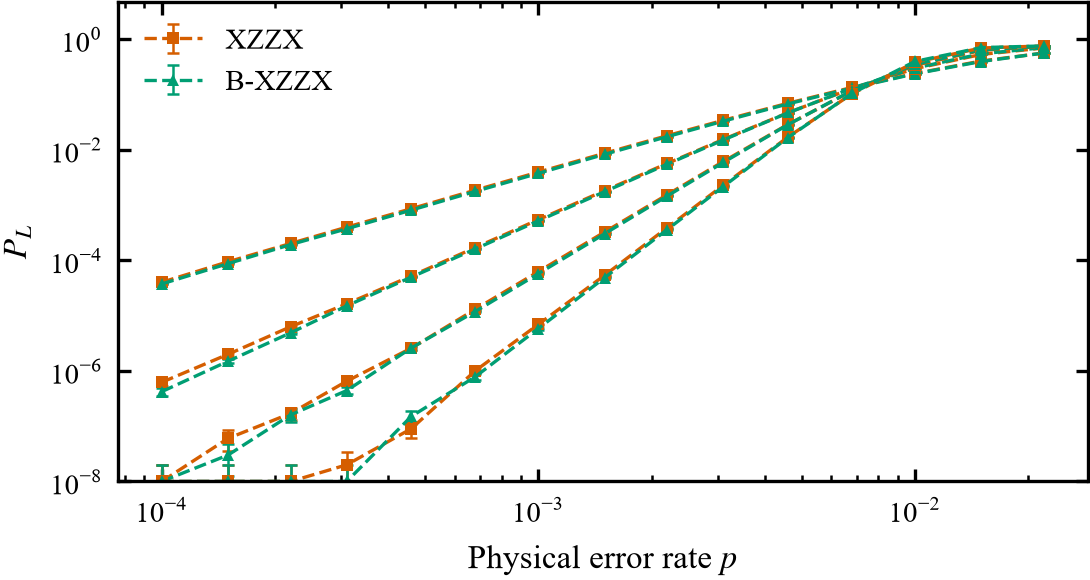

In [12]:
plt.figure(figsize=(3.7, 2))

first_call = True
for df in [p_sweep_3_df, p_sweep_5_df, p_sweep_7_df, p_sweep_9_df]:
    for group_name, group_entries in df.groupby("clifford_deformation"):
        # Get the data
        x = group_entries["p"].values
        y = group_entries["ler"].values
        y_err = group_entries["ler_unc"].values
        # Sort by x to ensure proper plotting
        sort_idx = np.argsort(x)
        x = x[sort_idx]
        y = y[sort_idx]
        y_err = y_err[sort_idx]
        # Plot the data
        label, color, shape = label_color_shape(group_name)
        if label == "CSS":
            continue
        errorbar(plt.gca(), x, y, yerr=y_err, label=label if first_call else None, fmt=f"--{shape}", color=color)
    first_call = False

plt.legend()
plt.loglog()

plt.xlabel("Physical error rate $p$")
plt.ylabel("$P_L$")
plt.ylim(ymin=1E-8)
# plt.xlim(xmin=1E-3)

plt.show()

# $\eta$ sweep

In [15]:
eta_sweep_3_df = load_ler_csv("../results/thresshold/SC3_MHBD_MWPM_eta_sweep/results.csv")
eta_sweep_5_df = load_ler_csv("../results/thresshold/SC5_MHBD_MWPM_eta_sweep/results.csv")
eta_sweep_7_df = load_ler_csv("../results/thresshold/SC7_MHBD_MWPM_eta_sweep/results.csv")
eta_sweep_9_df = load_ler_csv("../results/thresshold/SC9_MHBD_MWPM_eta_sweep/results.csv")

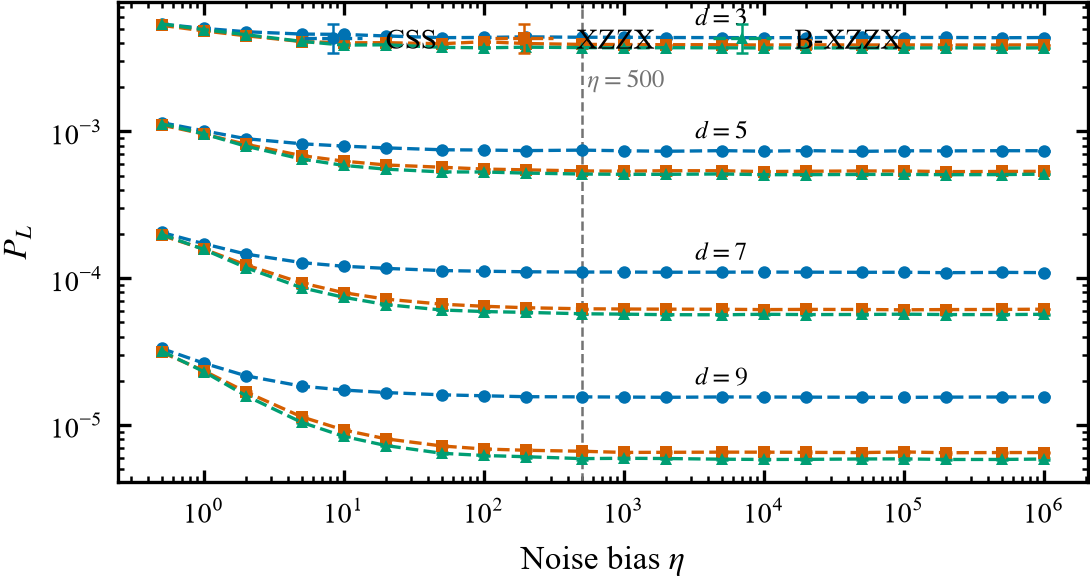

In [19]:
plt.figure(figsize=(3.7, 2))

first_call = True
for df in [eta_sweep_3_df, eta_sweep_5_df, eta_sweep_7_df, eta_sweep_9_df]:
    for group_name, group_entries in df.groupby("clifford_deformation"):
        # Get the data
        x = group_entries["eta"].values
        y = group_entries["ler"].values
        y_err = group_entries["ler_unc"].values
        # Sort by x to ensure proper plotting
        sort_idx = np.argsort(x)
        x = x[sort_idx]
        y = y[sort_idx]
        y_err = y_err[sort_idx]
        # Plot the data
        label, color, shape = label_color_shape(group_name)
        # if label == "CSS":
        #     continue
        errorbar(plt.gca(), x, y, yerr=y_err, label=label if first_call else None, fmt=f"--{shape}", color=color)
        # Plot code distance
        distance = group_entries["d"].values[0]
        if label == "CSS":
            plt.text(x[-8], y[-8]*1.1, f"$d={distance}$", fontsize=6, ha="center", va="bottom")
    first_call = False

plt.legend(ncols=4, loc="upper center")
plt.xscale("log")
plt.loglog()

plt.axvline(x=500, color="0.45", linestyle="--", linewidth=0.6)
plt.text(550, 1.8e-3, "$\\eta=500$", color="0.45", fontsize=6, ha="left", va="bottom")

plt.xlabel("Noise bias $\\eta$")
plt.ylabel("$P_L$")
# plt.ylim(ymin=1E-2)
# plt.xlim(xmin=1E-3)

plt.show()

# Proposed diagnostic panels

Everything below is additive: it only consumes `eta_sweep_*_df`, `load_ler_csv` and
`label_color_shape` from the cells above, and defines its own helpers. Nothing above is touched.

Distances and codes are discovered from the data, so when the distance-9 run lands the only
change needed is uncommenting `eta_sweep_9_df` above and adding it to `_frames` below.

In [20]:
ETA_PAPER = 500
CD_OF = {"CSS": "000", "XZZX": "030", "B-XZZX": "033", "XY": "222"}
LS = ["--", "-", ":", "-."]  # one line style per adjacent-distance pair

# Add eta_sweep_9_df here once the distance-9 run is done
_frames = [eta_sweep_3_df, eta_sweep_5_df, eta_sweep_7_df]

TIDY = pd.concat(_frames, ignore_index=True)
TIDY["code"] = [label_color_shape(cd)[0] for cd in TIDY["clifford_deformation"]]
DISTANCES = sorted(int(d) for d in TIDY["d"].unique())
CODES = [c for c in ["CSS", "XZZX", "B-XZZX", "XY"] if c in set(TIDY["code"])]
PAIRS = list(zip(DISTANCES[:-1], DISTANCES[1:]))


def series(code: str, d: int):
    """(eta, ler, ler_unc) for one code at one distance, sorted by eta."""
    s = TIDY[(TIDY.code == code) & (TIDY.d == d)].sort_values("eta")
    return s.eta.values, s.ler.values, s.ler_unc.values


def ratio(num, den):
    """Ratio of two `series` results, with uncertainty propagated in quadrature."""
    (e, y1, u1), (_, y0, u0) = num, den
    r = y1 / y0
    return e, r, r * np.sqrt((u1 / y1) ** 2 + (u0 / y0) ** 2)


def mark_eta(ax, y_frac=0.04, label=True):
    """Vertical marker at the bias used in the rest of the paper."""
    ax.axvline(ETA_PAPER, color="0.45", lw=0.6, ls="--", zorder=0)
    if label:
        lo, hi = ax.get_ylim()
        y = lo + y_frac * (hi - lo) if ax.get_yscale() == "linear" else lo * (hi / lo) ** y_frac
        ax.text(ETA_PAPER / 1.45, y, f"$\\eta={ETA_PAPER}$", fontsize=6,
                color="0.45", rotation=90, ha="center", va="bottom")


print("distances:", DISTANCES, " codes:", CODES, " repeats:", dict(TIDY.groupby("d").repeats.first()))

distances: [3, 5, 7]  codes: ['CSS', 'XZZX', 'B-XZZX']  repeats: {3: np.int64(1), 5: np.int64(1), 7: np.int64(10)}


## 1. Distance suppression $\Lambda$ vs $\eta$

How much bias buys you in *effective distance*, which is invisible in the $P_L$ plot because it
lives in the vertical gaps between curves. All three codes start at $\Lambda \approx 5.6$ under
depolarizing noise and separate under bias, with CSS as the control.

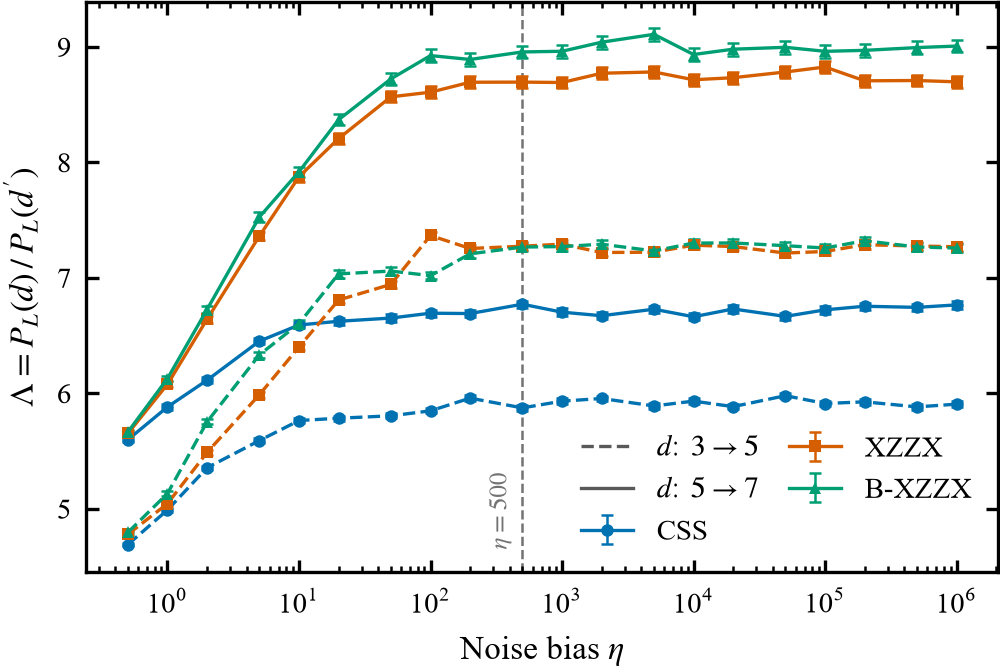

In [21]:
fig, ax = plt.subplots(figsize=(3.4, 2.3))

for code in CODES:
    _, color, shape = label_color_shape(CD_OF[code])
    for (d_lo, d_hi), ls in zip(PAIRS, LS):
        e, lam, err = ratio(series(code, d_lo), series(code, d_hi))
        errorbar(ax, e, lam, yerr=err, fmt=f"{ls}{shape}", color=color,
                 label=code if (d_lo, d_hi) == PAIRS[-1] else None)

# proxy handles so the line styles are decoded in the legend
for (d_lo, d_hi), ls in zip(PAIRS, LS):
    ax.plot([], [], ls, color="0.35", lw=0.8, label=f"$d\\!:\\,{d_lo}\\to{d_hi}$")

ax.set_xscale("log")
mark_eta(ax)
ax.set_xlabel("Noise bias $\\eta$")
ax.set_ylabel("$\\Lambda = P_L(d)\\,/\\,P_L(d')$")
ax.legend(ncol=2, loc="lower right", columnspacing=1.0, handlelength=1.8)

plt.show()

## 2. B-XZZX vs XZZX, resolved

The two deformations sit within one marker width of each other on a two-decade log axis, so the
$P_L$ plot cannot show this. Plotted as a ratio, the 10 repeats at distance-7 resolve a ~8%
advantage at 13–16$\sigma$, and the sign change near $\eta \approx 1$–2 becomes visible.
Shaded bands are $\pm 1\sigma$.

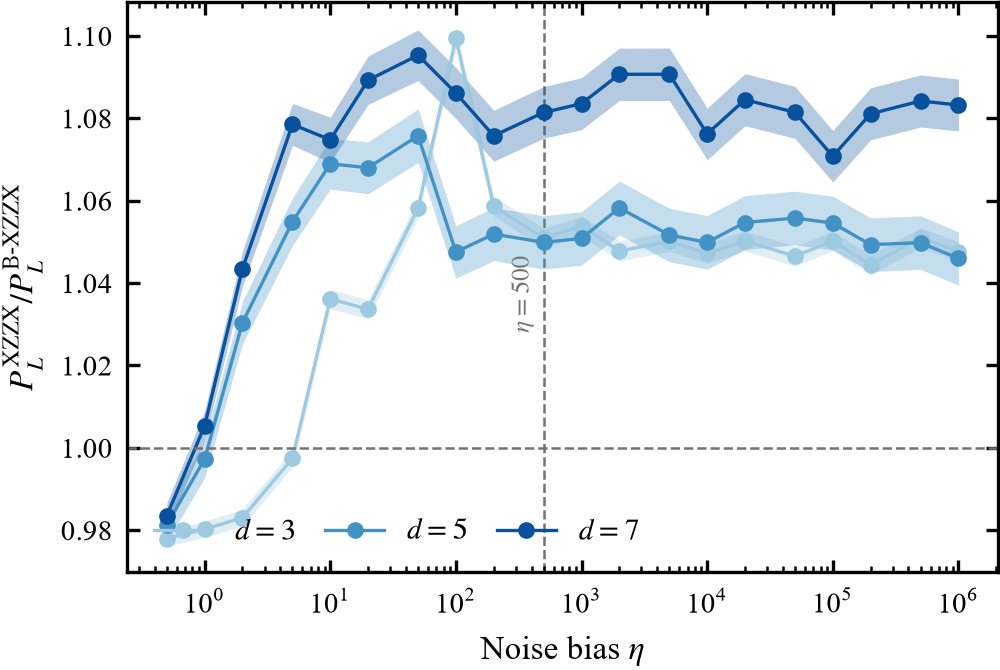

In [22]:
fig, ax = plt.subplots(figsize=(3.4, 2.3))

for d in DISTANCES:
    e, r, err = ratio(series("XZZX", d), series("B-XZZX", d))
    ax.plot(e, r, "-o", color=DCOL[d], markersize=3, lw=0.8, label=f"$d={d}$")
    ax.fill_between(e, r - err, r + err, color=DCOL[d], alpha=0.3, lw=0)

ax.axhline(1.0, color="0.45", ls="--", lw=0.6)
ax.set_xscale("log")
mark_eta(ax, y_frac=0.42)
ax.set_xlabel("Noise bias $\\eta$")
ax.set_ylabel(r"$P_L^{\mathrm{XZZX}} / P_L^{\text{B-XZZX}}$")
ax.legend(loc="lower left", ncol=len(DISTANCES), columnspacing=1.0)

plt.show()

## 3. Combined two-panel candidate for the paper

Your $P_L$ panel with CSS kept in as the control, stacked over $\Lambda$ on a shared $\eta$ axis.
This is the version I would put in the paper: panel (a) sets the scale, panel (b) carries the claim.

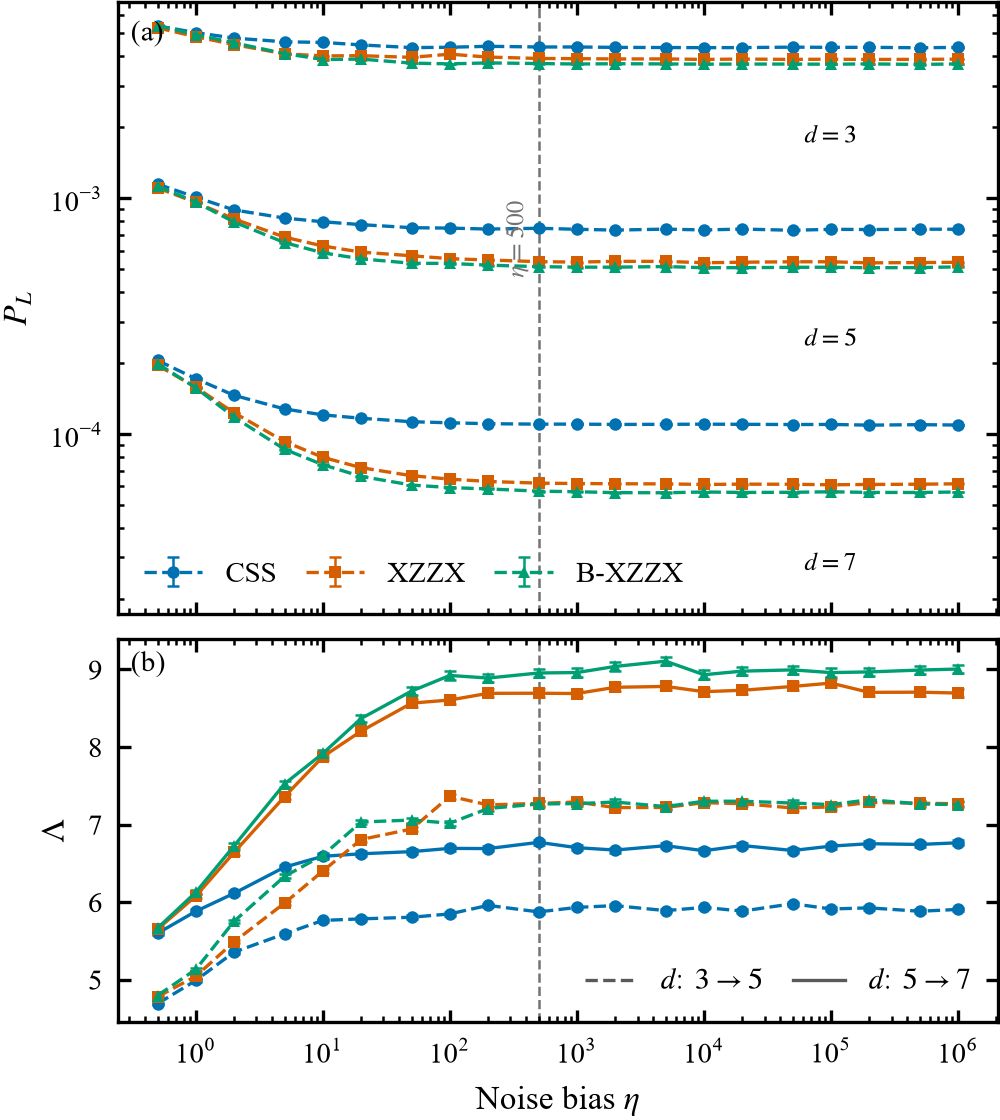

In [23]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(3.4, 3.8), sharex=True,
                               gridspec_kw={"height_ratios": [1.6, 1]})

# --- (a) raw LER ---
for code in CODES:
    _, color, shape = label_color_shape(CD_OF[code])
    for j, d in enumerate(DISTANCES):
        e, y, u = series(code, d)
        errorbar(ax0, e, y, yerr=u, fmt=f"--{shape}", color=color,
                 label=code if j == 0 else None)
ax0.set_yscale("log")
ax0.set_ylim(bottom=ax0.get_ylim()[0] / 2.6)  # headroom for the legend
for d in DISTANCES:
    e, y, _ = series(CODES[-1], d)
    ax0.text(e[-4], y[-4] * 0.55, f"$d={d}$", fontsize=6, ha="center", va="top")
ax0.set_ylabel("$P_L$")
ax0.legend(loc="lower left", ncol=3, columnspacing=1.0)

# --- (b) distance suppression ---
for code in CODES:
    _, color, shape = label_color_shape(CD_OF[code])
    for (d_lo, d_hi), ls in zip(PAIRS, LS):
        e, lam, err = ratio(series(code, d_lo), series(code, d_hi))
        errorbar(ax1, e, lam, yerr=err, fmt=f"{ls}{shape}", color=color)
for (d_lo, d_hi), ls in zip(PAIRS, LS):
    ax1.plot([], [], ls, color="0.35", lw=0.8, label=f"$d\\!:\\,{d_lo}\\to{d_hi}$")
ax1.set_xscale("log")
ax1.set_xlabel("Noise bias $\\eta$")
ax1.set_ylabel("$\\Lambda$")
ax1.legend(loc="lower right", ncol=2, columnspacing=1.0, handlelength=1.8)

for a, tag in ((ax0, "(a)"), (ax1, "(b)")):
    mark_eta(a, y_frac=0.55, label=(a is ax0))
    a.text(0.015, 0.97, tag, transform=a.transAxes, fontsize=7, va="top", ha="left")

# fig.savefig("outputs/parameter_sweeps/eta_sweep_combined.pdf", transparent=True)
plt.show()